## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix, hstack
import os
import random

## Data preprocessing

In [8]:
def preprocess_data(file_path):
    """
    Preprocess the product dataset for recommender system.
    
    Parameters:
    file_path (str): Path to the dataset file
    
    Returns:
    pd.DataFrame: Preprocessed dataframe
    """
    # Read dataset
    df = pd.read_csv(file_path, sep='\t')
    
    # Select relevant columns
    df = df[['Uniq Id', 'Product Id', 'Product Rating', 'Product Reviews Count', 
             'Product Category', 'Product Brand', 'Product Name', 
             'Product Image Url', 'Product Description', 'Product Tags']]
    
    # Fill missing values
    df['Product Rating'].fillna(0, inplace=True)
    df['Product Reviews Count'].fillna(0, inplace=True)
    df['Product Category'].fillna('', inplace=True)
    df['Product Brand'].fillna('', inplace=True)
    df['Product Description'].fillna('', inplace=True)
    df['Product Tags'].fillna('', inplace=True)
    
    # Rename columns to shorter names
    column_name_mapping = {
        'Uniq Id': 'ID',
        'Product Id': 'ProdID',
        'Product Rating': 'Rating',
        'Product Reviews Count': 'ReviewCount',
        'Product Category': 'Category',
        'Product Brand': 'Brand',
        'Product Name': 'Name',
        'Product Image Url': 'ImageURL',
        'Product Description': 'Description',
        'Product Tags': 'Tags'
    }
    df.rename(columns=column_name_mapping, inplace=True)
    
    # Create content feature by combining text fields
    df['Content'] = df['Name'] + ' ' + df['Brand'] + ' ' + df['Category'] + ' ' + df['Description'] + ' ' + df['Tags']
    
    print(f"Dataset loaded and preprocessed: {df.shape[0]} products with {df.shape[1]} features")
    return df

In [9]:
df=preprocess_data('G:\\Projects\\smart e-commerce project\\data\\marketing_sample_for_walmart_com-walmart_com_product_review__20200701_20201231__5k_data.tsv')

Dataset loaded and preprocessed: 5000 products with 11 features


In [10]:
df.head()

,ID,ProdID,Rating,ReviewCount,Category,Brand,Name,ImageURL,Description,Tags,Content
0,1705736792d82aa2f2d3caf1c07c53f4,2e17bf4acecdece67fc00f07ad62c910,0.0,0.0,Premium Beauty > Premium Makeup > Premium Nail...,OPI,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...",https://i5.walmartimages.com/asr/0e1f4c51-c1a4...,,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...","OPI Infinite Shine, Nail Lacquer Nail Polish, ..."
1,95a9fe6f4810fcfc7ff244fd06784f11,076e5854a62dd283c253d6bae415af1f,0.0,0.0,Beauty > Hair Care > Hair Color > Auburn Hair ...,Nice'n Easy,"Nice n Easy Permanent Color, 111 Natural Mediu...",https://i5.walmartimages.com/asr/9c8e42e4-13a5...,Pack of 3 Pack of 3 for the UPC: 381519000201 ...,"Nice 'n Easy Permanent Color, 111 Natural Medi...","Nice n Easy Permanent Color, 111 Natural Mediu..."
2,8d4d0330178d3ed181b15a4102b287f2,8a4fe5d9c7a6ed26cc44d785a454b124,4.5,29221.0,Beauty > Hair Care > Hair Color > Permanent Ha...,Clairol,Clairol Nice N Easy Permanent Color 7/106A Nat...,https://i5.walmartimages.com/asr/e3a601c2-6a2b...,This Clairol Nice N Easy Permanent Color gives...,Clairol Nice 'N Easy Permanent Color 7/106A Na...,Clairol Nice N Easy Permanent Color 7/106A Nat...
3,fddc4df45b35efd886794b261f730c51,03b5fb878a33eadff8b033419eab9669,0.0,0.0,Beauty > Makeup > Lip,Kokie Cosmetics,"Kokie Professional Matte Lipstick, Hot Berry, ...",https://i5.walmartimages.com/asr/25b4b467-bc61...,Calling all matte lip lovers! Indulge in our r...,"Kokie Professional Matte Lipstick, Hot Berry, ...","Kokie Professional Matte Lipstick, Hot Berry, ..."
4,0990cf89a59ca6a0460349a3e4f51d42,ce3d761e57d6ccad80619297b5b1bcbc,0.0,131.0,Seasonal > Stock Up Essentials > Personal Care...,Gillette,"Gillette TRAC II Plus Razor Blade Refills, Fit...",https://i5.walmartimages.com/asr/1a2ebb06-cd01...,"In 1971, Gillette introduced the Trac II razor...","Gillette TRAC II Plus Razor Blade Refills, Fit...","Gillette TRAC II Plus Razor Blade Refills, Fit..."


## EDA

In [11]:
df.shape

(5000, 11)

In [12]:
df.isna().sum()

ID             0
ProdID         0
Rating         0
ReviewCount    0
Category       0
Brand          0
Name           0
ImageURL       0
Description    0
Tags           0
Content        0
dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           5000 non-null   object 
 1   ProdID       5000 non-null   object 
 2   Rating       5000 non-null   float64
 3   ReviewCount  5000 non-null   float64
 4   Category     5000 non-null   object 
 5   Brand        5000 non-null   object 
 6   Name         5000 non-null   object 
 7   ImageURL     5000 non-null   object 
 8   Description  5000 non-null   object 
 9   Tags         5000 non-null   object 
 10  Content      5000 non-null   object 
dtypes: float64(2), object(9)
memory usage: 429.8+ KB


In [14]:
df.duplicated().sum()

0

Text(0, 0.5, 'Count')

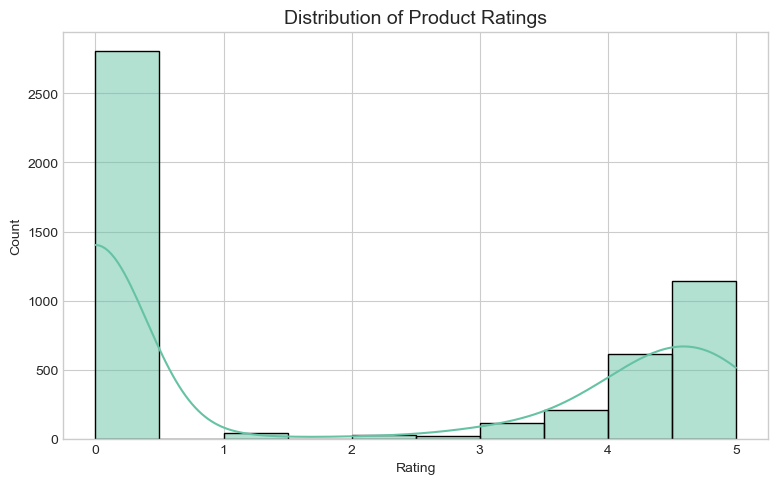

In [17]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
    
# Create a figure with subplots
fig = plt.figure(figsize=(20, 18))
    
# 1. Distribution of product ratings
plt.subplot(3, 2, 1)
sns.histplot(df['Rating'], bins=10, kde=True)
plt.title('Distribution of Product Ratings', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Count')

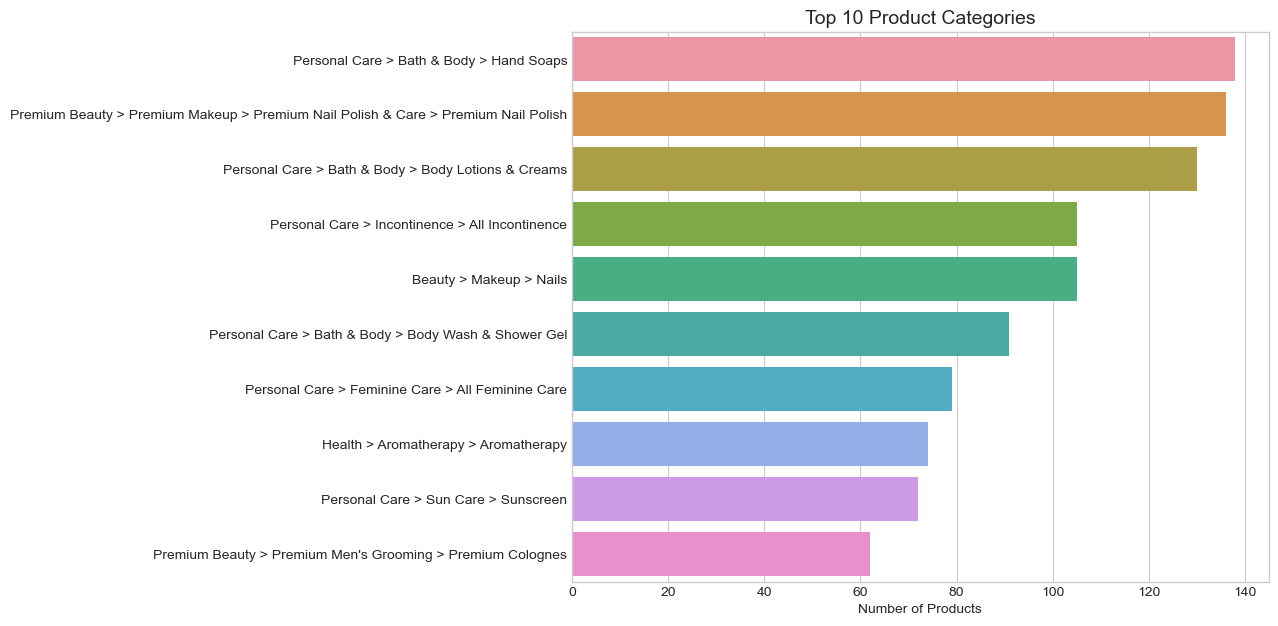

In [22]:
fig = plt.figure(figsize=(20, 18))

# 2. Top categories by number of products
plt.subplot(3, 2, 2)
category_counts = df['Category'].value_counts().head(10)
sns.barplot(x=category_counts.values, y=category_counts.index)
plt.title('Top 10 Product Categories', fontsize=14)
plt.xlabel('Number of Products')
plt.tight_layout()

Text(0.5, 0, 'Average Rating')

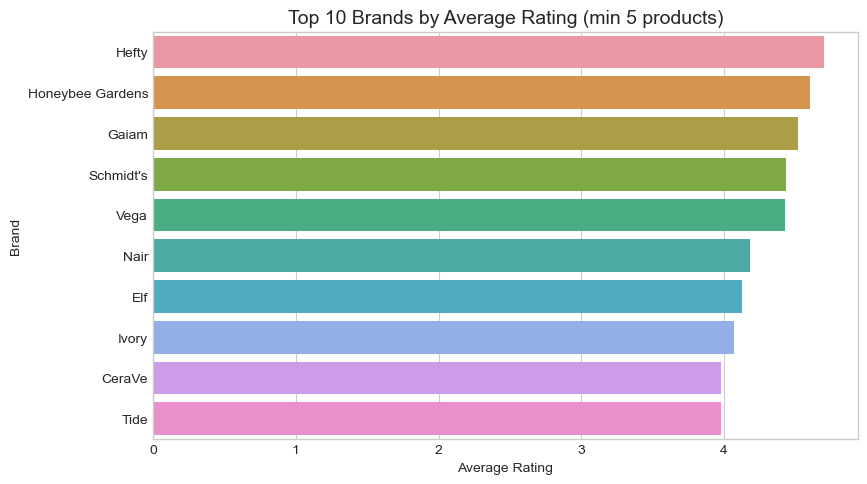

In [25]:
fig = plt.figure(figsize=(20, 18))

plt.subplot(3, 2, 4)
brand_ratings = df.groupby('Brand').agg({
        'Rating': ['mean', 'count']
    })
brand_ratings.columns = ['Avg Rating', 'Count']
top_brands = brand_ratings[brand_ratings['Count'] >= 5].sort_values('Avg Rating', ascending=False).head(10)
sns.barplot(x=top_brands['Avg Rating'], y=top_brands.index)
plt.title('Top 10 Brands by Average Rating (min 5 products)', fontsize=14)
plt.xlabel('Average Rating')

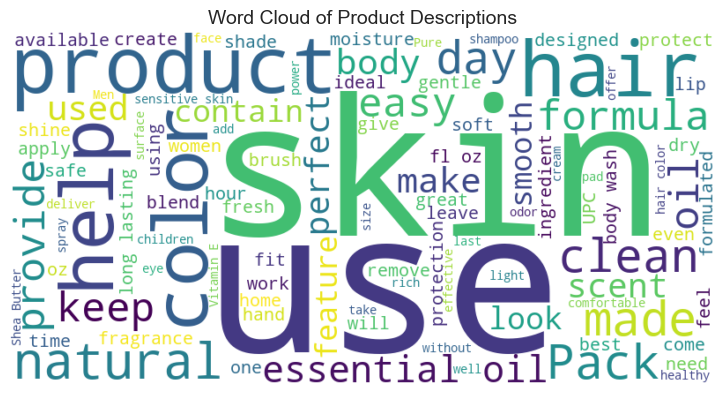

In [26]:
fig = plt.figure(figsize=(20, 18))


try:
    from wordcloud import WordCloud
    plt.subplot(3, 2, 5)
        
    # Combine all descriptions
    all_descriptions = ' '.join(df['Description'].dropna())
        
    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, 
                            background_color='white',
                            max_words=100).generate(all_descriptions)
        
    # Display the word cloud
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Product Descriptions', fontsize=14)
except ImportError:
    plt.subplot(3, 2, 5)
    plt.text(0.5, 0.5, "WordCloud package not available.\nInstall with: pip install wordcloud", 
                ha='center', va='center', fontsize=14)
    plt.axis('off')

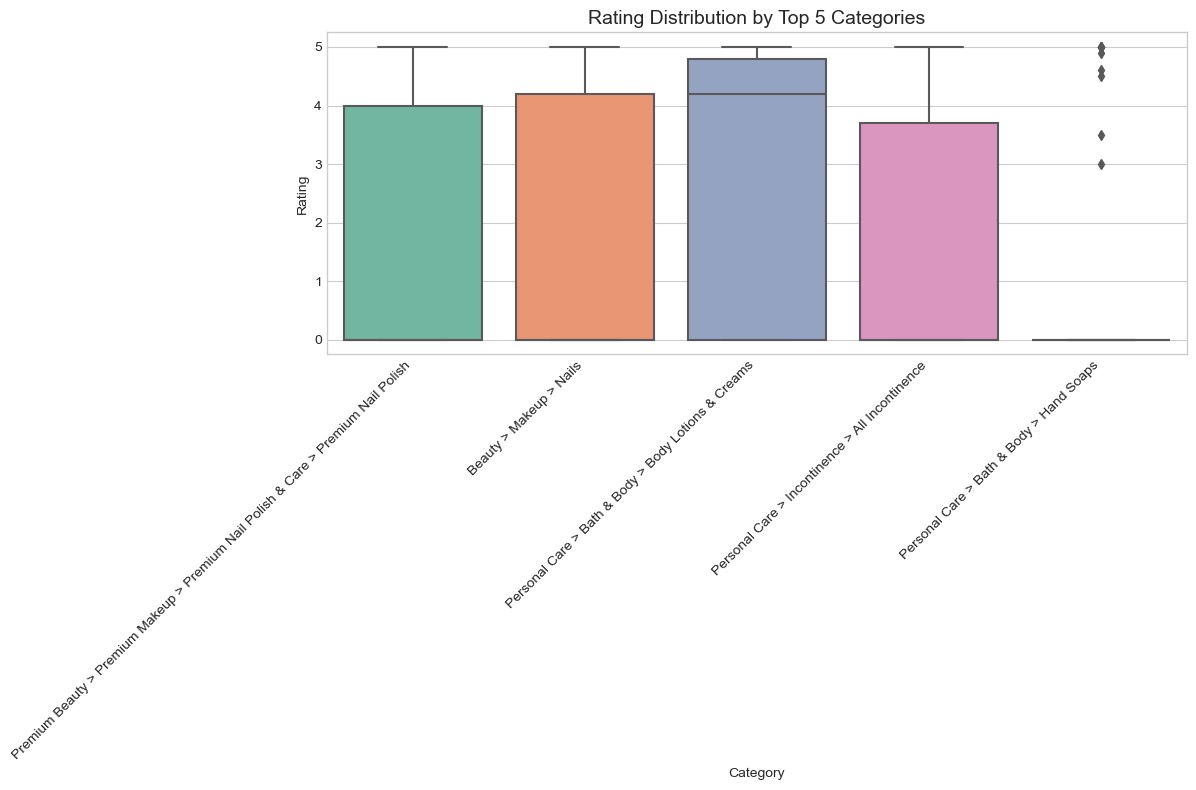

In [ ]:
plt.figure(figsize=(12, 8))

top_5_categories = df['Category'].value_counts().head(5).index
category_df = df[df['Category'].isin(top_5_categories)]
    
sns.boxplot(x='Category', y='Rating', data=category_df)
plt.title('Rating Distribution by Top 5 Categories', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## clean text and create tags

In [33]:
import re
import warnings
import time
from collections import Counter
import spacy

In [ ]:
# Try to import spaCy and load the English model
try:
    import spacy
    nlp = spacy.load("en_core_web_sm")
    SPACY_AVAILABLE = True
    ALL_STOP_WORDS = spacy.lang.en.stop_words.STOP_WORDS
    print("spaCy loaded, advanced NLP available.")
except (ImportError, OSError):
    SPACY_AVAILABLE = False
    # Fallback: simple stop-word list (augment as needed)
    ALL_STOP_WORDS = {
        "the", "and", "is", "in", "to", "of", "for", "on", "with", "a", "an"
    }
    print("spaCy not available, falling back to simple tokenization.")

def clean_text_and_create_tags(df):
    """
    Clean text data and create enhanced tags from product information.

    Parameters:
    df (pd.DataFrame): DataFrame with product data. Must contain columns
                       ['Name', 'Category', 'Brand', 'Description', 'Tags']

    Returns:
    pd.DataFrame: DataFrame with additional columns:
                  - Raw_<col> backups
                  - 'Tags': weighted, filtered tag string
                  - 'Content': combined field for TF-IDF
    """
    print("Cleaning text and generating enhanced tags...")
    start_time = time.time()

    def clean_and_extract_tags(text, min_token_length=3, max_token_length=20):
        if not isinstance(text, str) or not text.strip():
            return []

        # Lowercase & remove non-alphanumeric (except whitespace)
        text = re.sub(r"[^\w\s]", " ", text.lower())

        tags = []
        if SPACY_AVAILABLE:
            doc = nlp(text)
            for token in doc:
                t = token.text
                if (
                    t not in ALL_STOP_WORDS and
                    token.is_alpha and
                    not t.isdigit() and
                    min_token_length <= len(t) <= max_token_length
                ):
                    if token.pos_ in ["NOUN", "PROPN"]:
                        tags.append(t)
                    elif token.pos_ == "ADJ" and token.i + 1 < len(doc) and doc[token.i + 1].pos_ in ["NOUN", "PROPN"]:
                        tags.append(f"{t}_{doc[token.i + 1].text}")

            # Include certain named entities
            for ent in doc.ents:
                if ent.label_ in ["PRODUCT", "ORG", "PERSON", "GPE", "LOC", "WORK_OF_ART"]:
                    clean_ent = re.sub(r"[^\w\s]", " ", ent.text.lower()).strip()
                    if min_token_length <= len(clean_ent) <= max_token_length * 2:
                        tags.append(clean_ent.replace(" ", "_"))
        else:
            for token in text.split():
                if (
                    token not in ALL_STOP_WORDS and
                    token.isalnum() and
                    not token.isdigit() and
                    min_token_length <= len(token) <= max_token_length
                ):
                    tags.append(token)

        return tags

    # Columns to process
    cols = ["Name", "Category", "Brand", "Description", "Tags"]

    # Backup raw columns
    for col in cols:
        df[f"Raw_{col}"] = df[col].astype(str)

    # Extract tags per column
    for col in cols:
        print(f"  → processing '{col}'")
        df[f"{col}_tags"] = df[f"Raw_{col}"].apply(clean_and_extract_tags)

    # Combine tags and dedupe while preserving order
    df["Enhanced_Tags"] = df.apply(
        lambda row: list(dict.fromkeys(
            tag for col in cols for tag in row[f"{col}_tags"]
        )),
        axis=1
    )

    # Count global frequencies
    all_tags = [t for tags in df["Enhanced_Tags"] for t in tags]
    tag_counter = Counter(all_tags)

    # Frequency thresholds
    min_freq = 2
    max_freq = len(df) * 0.5

    # Filter by frequency
    df["Important_Tags"] = df["Enhanced_Tags"].apply(
        lambda tags: [t for t in tags if min_freq <= tag_counter[t] <= max_freq]
    )

    # Turn into weighted string
    def weighted_str(tags):
        return " ".join(sorted(tags, key=lambda t: -tag_counter[t])) if tags else ""

    df["Tags"] = df["Important_Tags"].apply(weighted_str)

    # Build final content field
    df["Content"] = (
        df["Raw_Name"] + " " +
        df["Raw_Brand"] + " " +
        df["Raw_Category"] + " " +
        df["Tags"] + " " +
        df["Raw_Description"]
    )

    # Clean up intermediate columns
    to_drop = [f"{col}_tags" for col in cols] + ["Enhanced_Tags", "Important_Tags"]
    df.drop(columns=to_drop, inplace=True)

    elapsed = time.time() - start_time
    print(f"Done in {elapsed:.2f}s.")
    return df

spaCy loaded, advanced NLP available.


In [37]:
df= clean_text_and_create_tags(df)
df[["Name", "Tags", "Content"]].head()

Cleaning text and generating enhanced tags...
  → processing 'Name'
  → processing 'Category'
  → processing 'Brand'
  → processing 'Description'
  → processing 'Tags'
Done in 174.66s.


,Name,Tags,Content
0,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...",beauty premium makeup bath nail polish premium...,"OPI Infinite Shine, Nail Lacquer Nail Polish, ..."
1,"Nice n Easy Permanent Color, 111 Natural Mediu...",beauty pack color formula oil hair ingredients...,"Nice n Easy Permanent Color, 111 Natural Mediu..."
2,Clairol Nice N Easy Permanent Color 7/106A Nat...,beauty color hair home quality conditioner shi...,Clairol Nice N Easy Permanent Color 7/106A Nat...
3,"Kokie Professional Matte Lipstick, Hot Berry, ...",beauty color makeup lip application lipstick m...,"Kokie Professional Matte Lipstick, Hot Berry, ..."
4,"Gillette TRAC II Plus Razor Blade Refills, Fit...",skin personal_care pack use face gel essential...,"Gillette TRAC II Plus Razor Blade Refills, Fit..."


## content recommender model

In [66]:
def build_content_model(product_df):
    """
    Build the content-based filtering model using TF-IDF and cosine similarity
    
    Parameters:
    product_df (pd.DataFrame): Preprocessed product dataframe with 'ProdID', 'Content', etc.
    
    Returns:
    dict: Content model with TF-IDF vectorizer, matrix and similarity matrix
    """
    print("Building content-based model...")
    start_time = time.time()
    
    # Create TF-IDF matrix
    tfidf = TfidfVectorizer(min_df=2, max_df=0.7, 
                           stop_words='english', 
                           ngram_range=(1, 2))
    
    tfidf_matrix = tfidf.fit_transform(product_df['Content'])
    
    # Calculate similarity matrix
    content_similarity = cosine_similarity(tfidf_matrix)
    
    # Create mapping dictionaries for product IDs to matrix indices
    prod_id_to_index = {prod_id: i for i, prod_id in enumerate(product_df['ProdID'])}
    index_to_prod_id = {i: prod_id for prod_id, i in prod_id_to_index.items()}
    
    content_model = {
        'tfidf': tfidf,
        'tfidf_matrix': tfidf_matrix,
        'similarity': content_similarity,
        'prod_id_to_index': prod_id_to_index,
        'index_to_prod_id': index_to_prod_id
    }
    
    elapsed = time.time() - start_time
    print(f"Content model built: {tfidf_matrix.shape[0]} products, {tfidf_matrix.shape[1]} features in {elapsed:.2f}s")
    return content_model

def get_content_recommendations(product_id, content_model, product_df, n=10):
    """
    Get content-based recommendations for a product
    
    Parameters:
    product_id (str): ID of the product to get recommendations for
    content_model (dict): Content-based model from build_content_model()
    product_df (pd.DataFrame): Product dataframe
    n (int): Number of recommendations to return
    
    Returns:
    pd.DataFrame: Recommended products with similarity scores
    """
    # Get the index of the product
    prod_idx = content_model['prod_id_to_index'].get(product_id)
    if prod_idx is None:
        print(f"Product ID {product_id} not found in the dataset")
        return pd.DataFrame()
    
    # Get similarity scores and indices of top n similar products
    sim_scores = list(enumerate(content_model['similarity'][prod_idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]  # Skip the first one (itself)
    product_indices = [i[0] for i in sim_scores]
    
    # Create recommendations dataframe
    recommendations = product_df.iloc[product_indices].copy()
    recommendations['Similarity'] = [i[1] for i in sim_scores]
    
    # Select columns to return
    columns_to_return = ['ProdID', 'Name', 'Category', 'Brand', 'Rating', 'Similarity']
    available_columns = [col for col in columns_to_return if col in recommendations.columns]
    
    return recommendations[available_columns]

def evaluate_content_model(content_model, product_df, n_test_products=50):
    """
    Evaluate content-based recommendations
    
    Parameters:
    content_model (dict): Content-based model
    product_df (pd.DataFrame): Product dataframe
    n_test_products (int): Number of products to use for testing
    
    Returns:
    dict: Evaluation metrics
    """
    print("\nEvaluating content-based model...")
    
    metrics = {'coverage': 0, 'category_diversity': 0, 'brand_diversity': 0, 'avg_similarity': 0}
    
    # Sample products for testing
    test_products = np.random.choice(
        list(content_model['prod_id_to_index'].keys()), 
        min(n_test_products, len(content_model['prod_id_to_index'])), 
        replace=False
    )
    
    all_recommendations = []
    for product_id in test_products:
        recs = get_content_recommendations(product_id, content_model, product_df, n=10)
        if not recs.empty:
            all_recommendations.extend(recs['ProdID'].tolist())
    
    # Calculate coverage (percentage of catalog that can be recommended)
    unique_recs = set(all_recommendations)
    metrics['coverage'] = len(unique_recs) / len(product_df) * 100
    
    # Calculate category diversity
    if 'Category' in product_df.columns:
        recommended_products = product_df[product_df['ProdID'].isin(unique_recs)]
        
        # Category diversity
        rec_categories = recommended_products['Category'].nunique()
        total_categories = product_df['Category'].nunique()
        metrics['category_diversity'] = rec_categories / total_categories * 100
        
        # Brand diversity
        if 'Brand' in product_df.columns:
            rec_brands = recommended_products['Brand'].nunique()
            total_brands = product_df['Brand'].nunique()
            metrics['brand_diversity'] = rec_brands / total_brands * 100
    
    # Calculate average similarity within recommendations
    avg_sim_scores = []
    for product_id in test_products[:20]:  # Limit to 20 for efficiency
        recs = get_content_recommendations(product_id, content_model, product_df, n=10)
        if len(recs) > 1:
            rec_indices = [content_model['prod_id_to_index'][pid] for pid in recs['ProdID'] if pid in content_model['prod_id_to_index']]
            if len(rec_indices) > 1:
                sim_sum = 0
                count = 0
                for i in range(len(rec_indices)):
                    for j in range(i+1, len(rec_indices)):
                        sim_sum += content_model['similarity'][rec_indices[i], rec_indices[j]]
                        count += 1
                if count > 0:
                    avg_sim_scores.append(sim_sum / count)
    
    if avg_sim_scores:
        metrics['avg_similarity'] = np.mean(avg_sim_scores)
    
    print(f"Content model evaluation:")
    print(f"  Coverage: {metrics['coverage']:.2f}%")
    print(f"  Category diversity: {metrics['category_diversity']:.2f}%")
    print(f"  Brand diversity: {metrics['brand_diversity']:.2f}%")
    print(f"  Avg similarity within recommendations: {metrics['avg_similarity']:.4f}")
    
    return metrics

def visualize_recommendations(product_id, recommendations, product_df):
    """
    Visualize recommendations for a product
    
    Parameters:
    product_id (str): ID of the reference product
    recommendations (pd.DataFrame): Recommendations from get_content_recommendations
    product_df (pd.DataFrame): Product dataframe
    """
    # Get reference product info
    ref_product = product_df[product_df['ProdID'] == product_id].iloc[0]
    
    # Create a figure with subplots
    plt.figure(figsize=(12, 8))
    
    # Plot similarity scores
    plt.subplot(211)
    
    # Create bar chart of similarities
    sns.barplot(x=recommendations['Name'], y=recommendations['Similarity'])
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Similarity Scores for Products Similar to: {ref_product["Name"]}')
    plt.xlabel('Product')
    plt.ylabel('Similarity Score')
    plt.tight_layout()
    
    print('\n\n')
    # If there's category information, show category distribution
    if 'Category' in recommendations.columns:
        plt.subplot(212)
        category_counts = recommendations['Category'].value_counts()
        sns.barplot(x=category_counts.index, y=category_counts.values)
        plt.xticks(rotation=45, ha='right')
        plt.title('Category Distribution in Recommendations')
        plt.xlabel('Category')
        plt.ylabel('Count')
        plt.tight_layout()
    
    plt.tight_layout(pad=3.0)
    plt.show()

def recommend_products(product_id, product_df, n=10, evaluate=True, visualize=False):
    """
    Generate content-based product recommendations
    
    Parameters:
    product_id (str): Product ID to base recommendations on
    product_df (pd.DataFrame): Product dataframe with 'ProdID' and 'Content' columns
    n (int): Number of recommendations to return
    evaluate (bool): Whether to evaluate the model
    visualize (bool): Whether to visualize the recommendations
    
    Returns:
    pd.DataFrame: Recommended products with similarity scores
    """
    # Check if product exists
    if product_id not in product_df['ProdID'].values:
        print(f"Product ID {product_id} not found in the dataset")
        return pd.DataFrame()
    
    # Get reference product info
    ref_product = product_df[product_df['ProdID'] == product_id].iloc[0]
    print(f"Finding recommendations for: {ref_product['Name']}")
    
    # Build content model
    content_model = build_content_model(product_df)
    
    # Get recommendations
    recommendations = get_content_recommendations(product_id, content_model, product_df, n)
    
    # Evaluate the model if requested
    if evaluate:
        metrics = evaluate_content_model(content_model, product_df)
    
    # Visualize recommendations if requested
    if visualize:
        visualize_recommendations(product_id, recommendations, product_df)
    
    return recommendations

Finding recommendations for: (6 pack) Great Value Marshmallows, 10 oz
Building content-based model...
Content model built: 5000 products, 93653 features in 2.18s

Evaluating content-based model...
Content model evaluation:
  Coverage: 9.20%
  Category diversity: 20.73%
  Brand diversity: 14.93%
  Avg similarity within recommendations: 0.2796





C:\Users\Mohamed Walid\AppData\Local\Temp\ipykernel_11544\1543954387.py:186: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()
C:\Users\Mohamed Walid\AppData\Local\Temp\ipykernel_11544\1543954387.py:188: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout(pad=3.0)


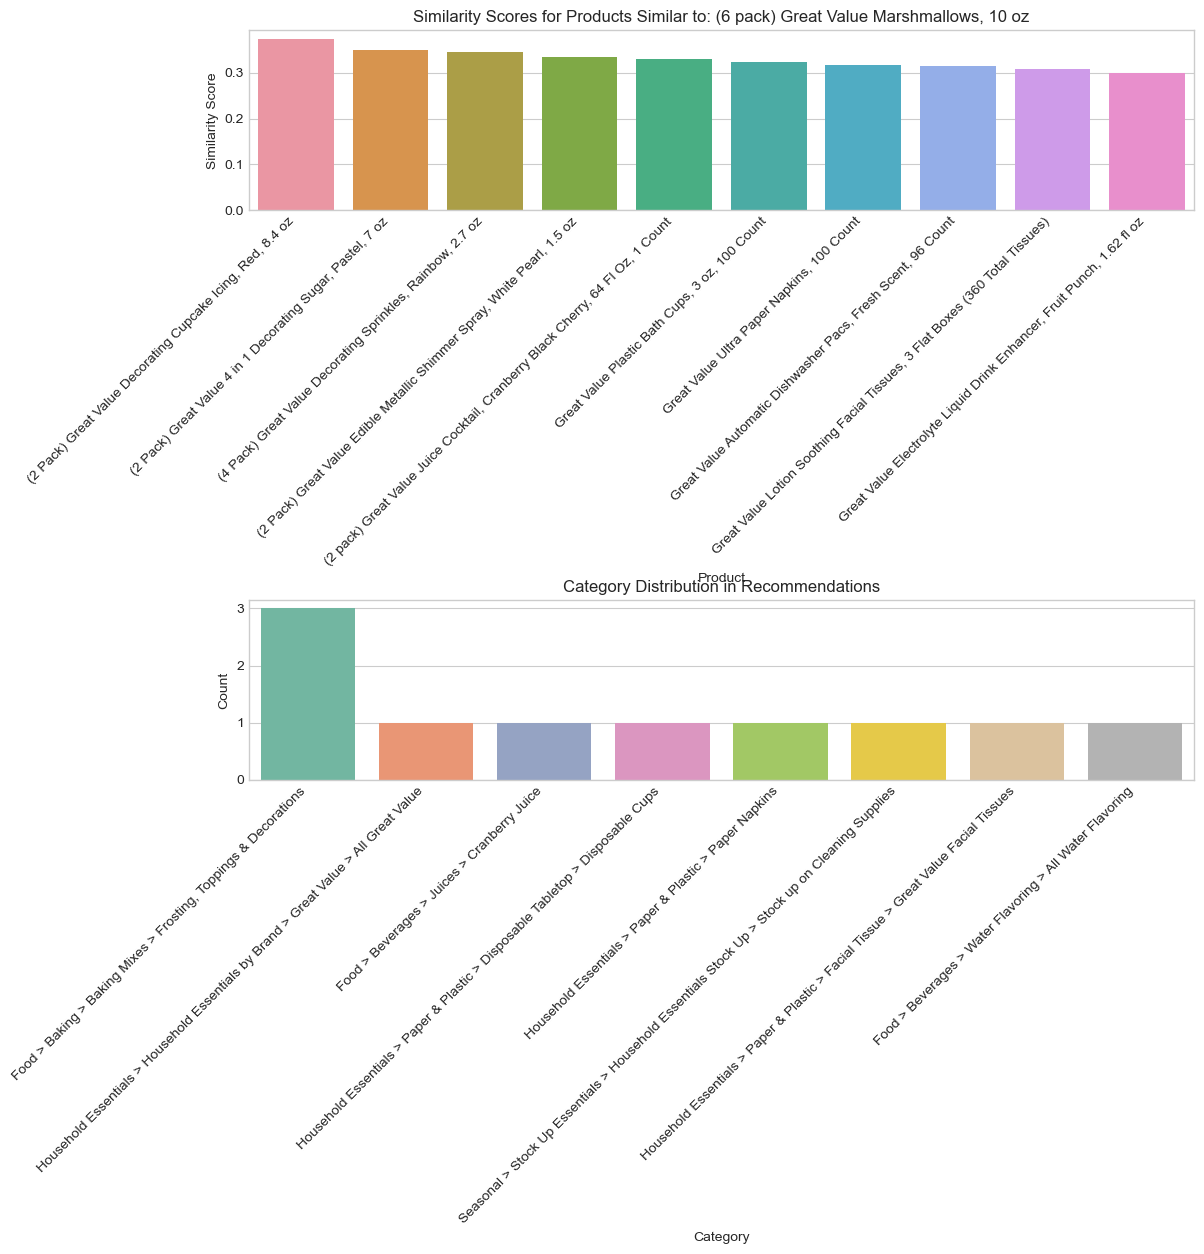


Top recommendations:
                                ProdID  \
4543  3afa1a2eaf44dc0d0247ef7090e2f10a   
3566  ad8a03ee27ac24d6d1eb131389e02973   
2517  f8440df8d6984c28e9146ea9ef38decd   
1986  3ded36ce865b548c0e23296fb2bdecd1   
3289  d71e05c117e8ebca062f07d0d75e5618   
2482  adf2968d0c03b07bc09753dcace138b1   
3356  647a99a063ff89705f839227178569e3   
637   cd0c7ad2974840265393d4fe48c5281b   
681   01b62f74620b01790965fa88a3335d6a   
3162  a1abe79ee054a1647bde31fc2dfc2d36   

                                                   Name  \
4543  (2 Pack) Great Value Decorating Cupcake Icing,...   
3566  (2 Pack) Great Value 4 in 1 Decorating Sugar, ...   
2517  (4 Pack) Great Value Decorating Sprinkles, Rai...   
1986  (2 Pack) Great Value Edible Metallic Shimmer S...   
3289  (2 pack) Great Value Juice Cocktail, Cranberry...   
2482     Great Value Plastic Bath Cups, 3 oz, 100 Count   
3356         Great Value Ultra Paper Napkins, 100 Count   
637   Great Value Automatic Dishwasher Pacs

In [67]:
random_product_id = df['ProdID'].sample(1).iloc[0]

# Get recommendations
recommendations = recommend_products(
    product_id=random_product_id,
    product_df=df,
    n=10,
    evaluate=True,
    visualize=True  # Set to True if you want visualization
)

print("\nTop recommendations:")
print(recommendations)

## Collaborative model

In [72]:
from sklearn.metrics import mean_squared_error

def build_collaborative_model(ratings_df, product_df, n_factors=20):
    """
    Build a collaborative filtering model using matrix factorization
    
    Parameters:
    ratings_df (pd.DataFrame): Dataframe with columns ['UserID', 'ProdID', 'Rating']
    product_df (pd.DataFrame): Product dataframe with 'ProdID' column
    n_factors (int): Number of latent factors for matrix factorization
    
    Returns:
    dict: Collaborative filtering model components
    """
    print("Building collaborative filtering model...")
    start_time = time.time()
    
    # Create mappings for users and items
    unique_users = ratings_df['UserID'].unique()
    unique_products = product_df['ProdID'].unique()
    
    user_to_idx = {user: i for i, user in enumerate(unique_users)}
    idx_to_user = {i: user for i, user in enumerate(unique_users)}
    
    prod_to_idx = {prod: i for i, prod in enumerate(unique_products)}
    idx_to_prod = {i: prod for i, prod in enumerate(unique_products)}
    
    # Calculate global mean rating
    global_mean = ratings_df['Rating'].mean()
    
    # Create sparse user-item ratings matrix
    n_users = len(unique_users)
    n_products = len(unique_products)
    
    # Build sparse matrix
    rows, cols, values = [], [], []
    for _, row in ratings_df.iterrows():
        user_idx = user_to_idx.get(row['UserID'])
        prod_idx = prod_to_idx.get(row['ProdID'])
        
        if user_idx is not None and prod_idx is not None:
            rows.append(user_idx)
            cols.append(prod_idx)
            values.append(row['Rating'])
    
    ratings_matrix = csr_matrix((values, (rows, cols)), shape=(n_users, n_products))
    
    # Calculate user and item biases (for better predictions)
    user_biases = np.zeros(n_users)
    item_biases = np.zeros(n_products)
    
    # Calculate user biases
    for user_idx in range(n_users):
        user_ratings = ratings_matrix[user_idx].data
        if len(user_ratings) > 0:
            user_biases[user_idx] = user_ratings.mean() - global_mean
    
    # Calculate item biases
    for item_idx in range(n_products):
        item_ratings = ratings_matrix.getcol(item_idx).data
        if len(item_ratings) > 0:
            item_biases[item_idx] = item_ratings.mean() - global_mean
    
    # Apply matrix factorization with SVD
    # Limit factors to avoid error when matrix has fewer entries than requested factors
    actual_n_factors = min(n_factors, min(n_users, n_products)-1)
    svd = TruncatedSVD(n_components=actual_n_factors, random_state=42)
    
    # Fit SVD on the item side of the matrix
    item_factors = svd.fit_transform(ratings_matrix.T)
    
    # Compute user factors
    user_factors = ratings_matrix.dot(item_factors) / actual_n_factors
    
    # Package model components
    collab_model = {
        'user_factors': user_factors,
        'item_factors': item_factors,
        'user_to_idx': user_to_idx,
        'idx_to_user': idx_to_user,
        'prod_to_idx': prod_to_idx,
        'idx_to_prod': idx_to_prod,
        'global_mean': global_mean,
        'user_biases': user_biases,
        'item_biases': item_biases,
        'ratings_matrix': ratings_matrix,
        'n_factors': actual_n_factors
    }
    
    elapsed = time.time() - start_time
    print(f"Collaborative model built: {n_users} users, {n_products} products, {actual_n_factors} factors")
    print(f"Explained variance: {sum(svd.explained_variance_ratio_):.4f}")
    print(f"Time elapsed: {elapsed:.2f}s")
    
    return collab_model

def get_collaborative_recommendations(user_id, collab_model, product_df, n=10):
    """
    Get collaborative filtering recommendations for a user
    
    Parameters:
    user_id (str): ID of the user to get recommendations for
    collab_model (dict): Collaborative model from build_collaborative_model()
    product_df (pd.DataFrame): Product dataframe
    n (int): Number of recommendations to return
    
    Returns:
    pd.DataFrame: Recommended products with predicted ratings
    """
    # Check if user exists in the model
    user_idx = collab_model['user_to_idx'].get(user_id)
    if user_idx is None:
        print(f"User {user_id} not found in the model. Using average user profile.")
        # Cold start: use average user factors
        user_factor = np.mean(collab_model['user_factors'], axis=0)
        user_bias = 0
    else:
        user_factor = collab_model['user_factors'][user_idx]
        user_bias = collab_model['user_biases'][user_idx]
    
    # Find items the user hasn't rated yet
    if user_idx is not None:
        rated_items = set(collab_model['ratings_matrix'][user_idx].indices)
    else:
        rated_items = set()
    
    # Calculate predicted ratings for all unrated items
    predictions = []
    for item_idx in range(len(collab_model['prod_to_idx'])):
        if item_idx not in rated_items:
            item_factor = collab_model['item_factors'][item_idx]
            item_bias = collab_model['item_biases'][item_idx]
            
            # Calculate predicted rating
            pred = (collab_model['global_mean'] + 
                   user_bias + 
                   item_bias + 
                   np.dot(user_factor, item_factor))
            
            # Clip to valid rating range (1-5)
            pred = max(1.0, min(5.0, pred))
            
            # Get the actual product ID
            prod_id = collab_model['idx_to_prod'][item_idx]
            
            # Add to predictions
            predictions.append((prod_id, pred))
    
    # Sort predictions by rating (descending)
    predictions.sort(key=lambda x: x[1], reverse=True)
    
    # Get top N predictions
    top_predictions = predictions[:n]
    
    # Get product details for recommendations
    rec_prod_ids = [p[0] for p in top_predictions]
    rec_ratings = [p[1] for p in top_predictions]
    
    # Create recommendations dataframe
    recommendations = product_df[product_df['ProdID'].isin(rec_prod_ids)].copy()
    
    # Add predicted ratings
    rating_dict = dict(zip(rec_prod_ids, rec_ratings))
    recommendations['Predicted_Rating'] = recommendations['ProdID'].map(rating_dict)
    
    # Sort by predicted rating
    recommendations = recommendations.sort_values('Predicted_Rating', ascending=False)
    
    # Select columns to return (ensuring they exist in the dataframe)
    columns_to_return = ['ProdID', 'Name', 'Category', 'Brand', 'Rating', 'Predicted_Rating']
    available_columns = [col for col in columns_to_return if col in recommendations.columns]
    
    return recommendations[available_columns]

def create_ratings_dataset(product_df, n_users=100, min_ratings=5, max_ratings=20, rating_dist=None):
    """
    Create a synthetic ratings dataset for testing collaborative filtering
    
    Parameters:
    product_df (pd.DataFrame): Product dataframe
    n_users (int): Number of synthetic users to create
    min_ratings (int): Minimum ratings per user
    max_ratings (int): Maximum ratings per user
    rating_dist (list): Optional distribution for ratings [p1, p2, p3, p4, p5]
    
    Returns:
    pd.DataFrame: Synthetic ratings with ['UserID', 'ProdID', 'Rating']
    """
    print(f"Creating synthetic ratings data with {n_users} users...")
    
    if rating_dist is None:
        # Use realistic rating distribution (skewed toward positive ratings)
        rating_dist = [0.05, 0.1, 0.2, 0.3, 0.35]
    
    # Create user IDs
    user_ids = [f'user_{i:04d}' for i in range(n_users)]
    
    # Get product IDs
    product_ids = product_df['ProdID'].values
    
    # Generate ratings
    ratings_data = []
    
    for user_id in user_ids:
        # Decide how many items this user will rate
        n_ratings = np.random.randint(min_ratings, min(max_ratings + 1, len(product_ids)))
        
        # Select random products
        rated_products = np.random.choice(product_ids, size=n_ratings, replace=False)
        
        for prod_id in rated_products:
            # Generate rating (1-5)
            rating = np.random.choice([1, 2, 3, 4, 5], p=rating_dist)
            
            ratings_data.append({
                'UserID': user_id,
                'ProdID': prod_id,
                'Rating': float(rating)
            })
    
    # Create dataframe
    ratings_df = pd.DataFrame(ratings_data)
    
    print(f"Created {len(ratings_df)} synthetic ratings")
    print(f"Average ratings per user: {len(ratings_df) / n_users:.1f}")
    
    return ratings_df

def evaluate_collaborative_model(collab_model, ratings_df, product_df, test_size=0.2):
    """
    Evaluate collaborative filtering model
    
    Parameters:
    collab_model (dict): Collaborative model
    ratings_df (pd.DataFrame): Ratings data
    product_df (pd.DataFrame): Product data
    test_size (float): Proportion of data to use for testing
    
    Returns:
    dict: Evaluation metrics
    """
    print("\nEvaluating collaborative filtering model...")
    
    # Split ratings into train and test sets
    np.random.seed(42)
    msk = np.random.rand(len(ratings_df)) < (1 - test_size)
    train_df = ratings_df[msk]
    test_df = ratings_df[~msk]
    
    # Make sure test users and items exist in training data
    test_df = test_df[test_df['UserID'].isin(train_df['UserID'])]
    test_df = test_df[test_df['ProdID'].isin(train_df['ProdID'])]
    
    if len(test_df) == 0:
        print("No valid test data after filtering")
        return {}
    
    # Make predictions on test set
    actual_ratings = []
    predicted_ratings = []
    
    for _, row in test_df.iterrows():
        user_id = row['UserID']
        prod_id = row['ProdID']
        actual = row['Rating']
        
        # Get indices
        user_idx = collab_model['user_to_idx'].get(user_id)
        prod_idx = collab_model['prod_to_idx'].get(prod_id)
        
        if user_idx is not None and prod_idx is not None:
            # Calculate prediction
            user_factor = collab_model['user_factors'][user_idx]
            item_factor = collab_model['item_factors'][prod_idx]
            user_bias = collab_model['user_biases'][user_idx]
            item_bias = collab_model['item_biases'][prod_idx]
            
            pred = (collab_model['global_mean'] + 
                   user_bias + 
                   item_bias + 
                   np.dot(user_factor, item_factor))
            
            # Clip to valid range
            pred = max(1.0, min(5.0, pred))
            
            actual_ratings.append(actual)
            predicted_ratings.append(pred)
    
    if not actual_ratings:
        print("No valid predictions for evaluation")
        return {}
    
    # Calculate error metrics
    rmse = np.sqrt(mean_squared_error(actual_ratings, predicted_ratings))
    mae = np.mean(np.abs(np.array(predicted_ratings) - np.array(actual_ratings)))
    
    # Calculate coverage
    n_possible_products = len(collab_model['prod_to_idx'])
    
    # Get a sample of users to check coverage
    sample_users = np.random.choice(list(collab_model['user_to_idx'].keys()), 
                                   min(10, len(collab_model['user_to_idx'])), 
                                   replace=False)
    
    recommended_products = set()
    for user_id in sample_users:
        recs = get_collaborative_recommendations(user_id, collab_model, product_df, n=10)
        if not recs.empty:
            recommended_products.update(recs['ProdID'].values)
    
    catalog_coverage = len(recommended_products) / n_possible_products * 100
    
    # Package metrics
    metrics = {
        'rmse': rmse,
        'mae': mae,
        'test_samples': len(actual_ratings),
        'catalog_coverage': catalog_coverage
    }
    
    print(f"Collaborative model evaluation:")
    print(f"  RMSE: {metrics['rmse']:.4f}")
    print(f"  MAE: {metrics['mae']:.4f}")
    print(f"  Test samples: {metrics['test_samples']}")
    print(f"  Catalog coverage (sample): {metrics['catalog_coverage']:.2f}%")
    
    return metrics

def visualize_collaborative_recommendations(user_id, recommendations):
    """
    Visualize collaborative filtering recommendations
    
    Parameters:
    user_id (str): User ID
    recommendations (pd.DataFrame): Recommendations from get_collaborative_recommendations
    """
    plt.figure(figsize=(12, 8))
    
    # Plot predicted ratings
    plt.subplot(211)
    plt.barh(recommendations['Name'], recommendations['Predicted_Rating'], color='salmon')
    plt.xlim(1, 5)
    plt.title(f'Predicted Ratings for User {user_id}')
    plt.xlabel('Predicted Rating')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Plot category distribution if available
    if 'Category' in recommendations.columns:
        plt.subplot(212)
        categories = recommendations['Category'].value_counts()
        plt.pie(categories, labels=categories.index, autopct='%1.1f%%')
        plt.title('Category Distribution in Recommendations')
        plt.axis('equal')
    
    plt.tight_layout()
    plt.show()

def recommend_products_collaborative(user_id, product_df, n=10, create_synthetic=True, 
                                    n_users=100, n_factors=20, evaluate=True, visualize=False):
    """
    Generate collaborative filtering recommendations for a user
    
    Parameters:
    user_id (str): ID of the user (will use random ID from synthetic data if not provided)
    product_df (pd.DataFrame): Product dataframe
    n (int): Number of recommendations to return
    create_synthetic (bool): Whether to create synthetic ratings data
    n_users (int): Number of synthetic users if creating data
    n_factors (int): Number of latent factors for matrix factorization
    evaluate (bool): Whether to evaluate the model
    visualize (bool): Whether to visualize recommendations
    
    Returns:
    pd.DataFrame: Recommended products with predicted ratings
    """
    # Create synthetic ratings if requested
    if create_synthetic:
        ratings_df = create_ratings_dataset(product_df, n_users=n_users)
        
        # Use a random user ID if none provided
        if user_id is None or user_id not in ratings_df['UserID'].unique():
            user_id = np.random.choice(ratings_df['UserID'].unique())
            print(f"Using random user ID: {user_id}")
    else:
        # If we're not creating synthetic data, we should be provided with a ratings dataframe
        print("Need to provide ratings_df when create_synthetic=False")
        return pd.DataFrame()
    
    # Build collaborative filtering model
    collab_model = build_collaborative_model(ratings_df, product_df, n_factors=n_factors)
    
    # Get recommendations for the user
    recommendations = get_collaborative_recommendations(user_id, collab_model, product_df, n=n)
    
    # Evaluate the model if requested
    if evaluate:
        metrics = evaluate_collaborative_model(collab_model, ratings_df, product_df)
    
    # Visualize recommendations if requested
    if visualize:
        visualize_collaborative_recommendations(user_id, recommendations)
    
    return recommendations

Creating synthetic ratings data with 100 users...
Created 1224 synthetic ratings
Average ratings per user: 12.2
Using random user ID: user_0043
Building collaborative filtering model...
Collaborative model built: 100 users, 4802 products, 20 factors
Explained variance: 0.3163
Time elapsed: 0.28s

Evaluating collaborative filtering model...
Collaborative model evaluation:
  RMSE: 1.5415
  MAE: 1.0906
  Test samples: 45
  Catalog coverage (sample): 0.92%


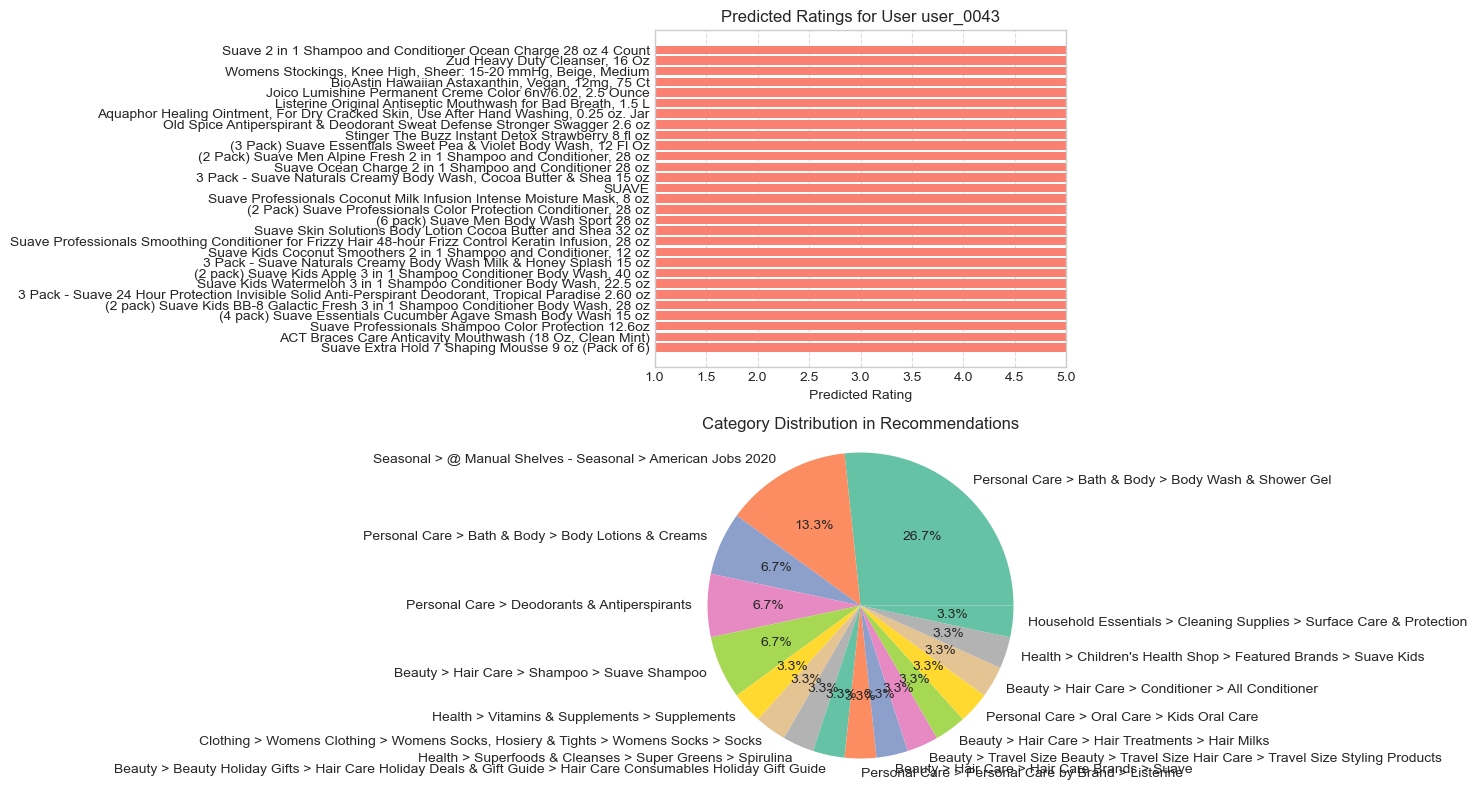


Top Collaborative Recommendations:
                                             ProdID  \
8     1007940052235879400000002000000000067565785US   
22                 dd0b56b42f648895495b17bf39d284dd   
4737  1007940052235879400000002000000000067565785US   
4500  1007940052235879400000002000000000067565785US   
4347  1007940052235879400000002000000000067565785US   
3878  1007940052235879400000002000000000067565785US   
3266  1007940052235879400000002000000000067565785US   
2502  1007940052235879400000002000000000067565785US   
2347  1007940052235879400000002000000000067565785US   
2064  1007940052235879400000002000000000067565785US   
2060  1007940052235879400000002000000000067565785US   
1723  1007940052235879400000002000000000067565785US   
1713  1007940052235879400000002000000000067565785US   
1597  1007940052235879400000002000000000067565785US   
1421  1007940052235879400000002000000000067565785US   
1415  1007940052235879400000002000000000067565785US   
1169  10079400522358794000000

In [73]:
# Get recommendations using the collaborative filtering system
collaborative_recommendations = recommend_products_collaborative(
    user_id=None,  # Will use a random synthetic user
    product_df=df,  # Your product dataframe (df is already defined)
    n=10,
    create_synthetic=True,
    n_users=100,
    n_factors=20,
    evaluate=True,
    visualize=True
)

print("\nTop Collaborative Recommendations:")
print(collaborative_recommendations)

## Hybrid-based model

In [74]:
from sklearn.preprocessing import MinMaxScaler

def build_hybrid_recommender(product_df, n_users=100, n_factors_collab=20, 
                           content_weight=0.5, collab_weight=0.5):
    """
    Build a hybrid recommender system combining content-based and collaborative filtering
    
    Parameters:
    product_df (pd.DataFrame): Product dataframe
    n_users (int): Number of synthetic users for collaborative filtering
    n_factors_collab (int): Number of factors for collaborative filtering
    content_weight (float): Weight for content-based recommendations (0-1)
    collab_weight (float): Weight for collaborative recommendations (0-1)
    
    Returns:
    dict: Hybrid recommender model components
    """
    print("Building hybrid recommender system...")
    start_time = time.time()
    
    # 1. Build content-based model
    content_model = build_content_model(product_df)
    
    # 2. Create synthetic ratings and build collaborative model
    ratings_df = create_ratings_dataset(product_df, n_users=n_users)
    collab_model = build_collaborative_model(ratings_df, product_df, n_factors=n_factors_collab)
    
    # 3. Package hybrid model
    hybrid_model = {
        'content_model': content_model,
        'collab_model': collab_model,
        'ratings_df': ratings_df,
        'content_weight': content_weight,
        'collab_weight': collab_weight
    }
    
    elapsed = time.time() - start_time
    print(f"Hybrid recommender built in {elapsed:.2f}s")
    
    return hybrid_model

def get_hybrid_recommendations(user_id, product_id, hybrid_model, product_df, n=10, 
                             dynamic_weighting=False):
    """
    Generate hybrid recommendations using ensemble methods
    
    Parameters:
    user_id (str): User ID for collaborative filtering
    product_id (str): Product ID for content-based filtering
    hybrid_model (dict): Hybrid model from build_hybrid_recommender
    product_df (pd.DataFrame): Product dataframe
    n (int): Number of recommendations to return
    dynamic_weighting (bool): Whether to use dynamic weighting based on user history
    
    Returns:
    pd.DataFrame: Recommended products with hybrid scores
    """
    # Extract models
    content_model = hybrid_model['content_model']
    collab_model = hybrid_model['collab_model']
    ratings_df = hybrid_model['ratings_df']
    
    # Default weights
    content_weight = hybrid_model['content_weight']
    collab_weight = hybrid_model['collab_weight']
    
    # Check if user exists in the collaborative model
    user_exists = user_id in collab_model['user_to_idx']
    
    # Adjust weights dynamically if requested
    if dynamic_weighting:
        if user_exists:
            # Get user's rating count
            user_ratings = ratings_df[ratings_df['UserID'] == user_id]
            rating_count = len(user_ratings)
            
            # Adjust weights based on user history
            # More ratings = higher weight to collaborative filtering
            if rating_count > 20:
                collab_weight = 0.7
                content_weight = 0.3
            elif rating_count > 10:
                collab_weight = 0.6
                content_weight = 0.4
            elif rating_count > 5:
                collab_weight = 0.5
                content_weight = 0.5
            else:
                collab_weight = 0.4
                content_weight = 0.6
        else:
            # Cold start: rely more on content
            collab_weight = 0.3
            content_weight = 0.7
    
    # Normalize weights
    total_weight = content_weight + collab_weight
    content_weight = content_weight / total_weight
    collab_weight = collab_weight / total_weight
    
    print(f"Using weights: Content={content_weight:.2f}, Collaborative={collab_weight:.2f}")
    
    # Get recommendations from both models (get more than needed for better ensemble)
    content_recs = get_content_recommendations(product_id, content_model, product_df, n=n*2)
    collab_recs = get_collaborative_recommendations(user_id, collab_model, product_df, n=n*2)
    
    # Create dictionaries of recommendations with scores
    content_scores = {}
    if not content_recs.empty:
        # Normalize similarity scores to 0-1 range
        min_sim = content_recs['Similarity'].min()
        max_sim = content_recs['Similarity'].max()
        range_sim = max_sim - min_sim if max_sim > min_sim else 1
        
        for _, row in content_recs.iterrows():
            norm_sim = (row['Similarity'] - min_sim) / range_sim if range_sim > 0 else 0.5
            content_scores[row['ProdID']] = norm_sim
    
    collab_scores = {}
    if not collab_recs.empty:
        # Normalize predicted ratings to 0-1 range
        min_rating = collab_recs['Predicted_Rating'].min()
        max_rating = collab_recs['Predicted_Rating'].max()
        range_rating = max_rating - min_rating if max_rating > min_rating else 1
        
        for _, row in collab_recs.iterrows():
            norm_rating = (row['Predicted_Rating'] - min_rating) / range_rating if range_rating > 0 else 0.5
            collab_scores[row['ProdID']] = norm_rating
    
    # Combine scores using weighted ensemble
    ensemble_scores = {}
    
    # Get all unique product IDs from both recommendation sets
    all_products = set(content_scores.keys()) | set(collab_scores.keys())
    
    for prod_id in all_products:
        # Get scores from each model (default to 0 if not available)
        content_score = content_scores.get(prod_id, 0)
        collab_score = collab_scores.get(prod_id, 0)
        
        # Weighted average
        ensemble_score = (content_weight * content_score) + (collab_weight * collab_score)
        ensemble_scores[prod_id] = ensemble_score
    
    # Get top N products by ensemble score
    top_products = sorted(ensemble_scores.items(), key=lambda x: x[1], reverse=True)[:n]
    
    # Create recommendations dataframe
    rec_prod_ids = [p[0] for p in top_products]
    rec_scores = [p[1] for p in top_products]
    
    recommendations = product_df[product_df['ProdID'].isin(rec_prod_ids)].copy()
    
    # Add scores to the recommendations
    score_dict = dict(zip(rec_prod_ids, rec_scores))
    recommendations['Hybrid_Score'] = recommendations['ProdID'].map(score_dict)
    
    # Add individual model scores where available
    recommendations['Content_Score'] = recommendations['ProdID'].map(
        lambda x: content_scores.get(x, np.nan))
    recommendations['Collab_Score'] = recommendations['ProdID'].map(
        lambda x: collab_scores.get(x, np.nan))
    
    # Sort by hybrid score
    recommendations = recommendations.sort_values('Hybrid_Score', ascending=False)
    
    # Select columns to return
    cols_to_return = ['ProdID', 'Name', 'Category', 'Brand', 'Rating', 
                     'Hybrid_Score', 'Content_Score', 'Collab_Score']
    available_cols = [col for col in cols_to_return if col in recommendations.columns]
    
    return recommendations[available_cols]



In [75]:
def evaluate_hybrid_model(hybrid_model, product_df):
    """
    Evaluate the hybrid recommender system
    
    Parameters:
    hybrid_model (dict): Hybrid model from build_hybrid_recommender
    product_df (pd.DataFrame): Product dataframe
    
    Returns:
    dict: Evaluation metrics
    """
    print("\nEvaluating hybrid recommender system...")
    
    # Extract components
    content_model = hybrid_model['content_model']
    collab_model = hybrid_model['collab_model']
    ratings_df = hybrid_model['ratings_df']
    
    # 1. Sample products and users for testing
    test_products = np.random.choice(list(content_model['prod_id_to_index'].keys()), 
                                    min(20, len(content_model['prod_id_to_index'])), 
                                    replace=False)
    
    test_users = np.random.choice(list(collab_model['user_to_idx'].keys()),
                                 min(10, len(collab_model['user_to_idx'])),
                                 replace=False)
    
    # 2. Compare recommendations from each model
    diversity_scores = []
    novelty_scores = []
    
    for user_id in test_users:
        for product_id in test_products[:2]:  # Limit products per user for efficiency
            # Get recommendations from each model
            content_recs = get_content_recommendations(product_id, content_model, product_df, n=10)
            collab_recs = get_collaborative_recommendations(user_id, collab_model, product_df, n=10)
            hybrid_recs = get_hybrid_recommendations(user_id, product_id, hybrid_model, product_df, n=10)
            
            if not content_recs.empty and not collab_recs.empty and not hybrid_recs.empty:
                # Calculate diversity as the uniqueness of recommendations
                content_ids = set(content_recs['ProdID'])
                collab_ids = set(collab_recs['ProdID'])
                hybrid_ids = set(hybrid_recs['ProdID'])
                
                # Overlap between models
                content_collab_overlap = len(content_ids & collab_ids) / len(content_ids | collab_ids)
                
                # Diversity - how many unique items from both models are in hybrid
                hybrid_diversity = len(hybrid_ids - (content_ids & collab_ids)) / len(hybrid_ids) if hybrid_ids else 0
                
                # Novelty - items in hybrid that weren't in either individual model
                hybrid_novelty = len(hybrid_ids - (content_ids | collab_ids)) / len(hybrid_ids) if hybrid_ids else 0
                
                diversity_scores.append(hybrid_diversity)
                novelty_scores.append(hybrid_novelty)
    
    # 3. Category coverage
    if 'Category' in product_df.columns:
        all_categories = set(product_df['Category'].unique())
        hybrid_categories = set()
        
        for user_id in test_users[:5]:
            for product_id in test_products[:5]:
                hybrid_recs = get_hybrid_recommendations(user_id, product_id, hybrid_model, product_df, n=10)
                if not hybrid_recs.empty and 'Category' in hybrid_recs.columns:
                    hybrid_categories.update(hybrid_recs['Category'].unique())
        
        category_coverage = len(hybrid_categories) / len(all_categories) * 100
    else:
        category_coverage = 0
    
    # 4. Prepare metrics
    metrics = {
        'avg_diversity': np.mean(diversity_scores) if diversity_scores else 0,
        'avg_novelty': np.mean(novelty_scores) if novelty_scores else 0,
        'category_coverage': category_coverage
    }
    
    print(f"Hybrid model evaluation:")
    print(f"  Average diversity: {metrics['avg_diversity']:.4f}")
    print(f"  Average novelty: {metrics['avg_novelty']:.4f}")
    print(f"  Category coverage: {metrics['category_coverage']:.2f}%")
    
    return metrics

def visualize_hybrid_recommendations(user_id, product_id, hybrid_recs, content_recs, collab_recs):
    """
    Visualize hybrid recommendations compared to individual models
    
    Parameters:
    user_id (str): User ID
    product_id (str): Product ID
    hybrid_recs (pd.DataFrame): Hybrid recommendations
    content_recs (pd.DataFrame): Content-based recommendations
    collab_recs (pd.DataFrame): Collaborative recommendations
    """
    plt.figure(figsize=(15, 10))
    
    # 1. Bar chart comparing recommendation scores
    plt.subplot(211)
    
    # Get overlapping products
    common_products = set(hybrid_recs['ProdID']) & set(content_recs['ProdID']) & set(collab_recs['ProdID'])
    
    if common_products:
        # Filter to common products
        common_product = list(common_products)[0]  # Just use the first one for illustration
        product_name = hybrid_recs[hybrid_recs['ProdID'] == common_product]['Name'].iloc[0]
        
        # Create comparison data
        comparison_data = {
            'Content': content_recs[content_recs['ProdID'] == common_product]['Similarity'].iloc[0],
            'Collaborative': collab_recs[collab_recs['ProdID'] == common_product]['Predicted_Rating'].iloc[0] / 5,
            'Hybrid': hybrid_recs[hybrid_recs['ProdID'] == common_product]['Hybrid_Score'].iloc[0]
        }
        
        # Plot
        plt.bar(comparison_data.keys(), comparison_data.values(), color=['blue', 'green', 'red'])
        plt.title(f'Score Comparison for "{product_name}" Across Models')
        plt.ylabel('Normalized Score')
        plt.ylim(0, 1)
        
    # 2. Venn diagram showing recommendation overlap
    plt.subplot(212)
    
    # Get sets of recommendations from each model
    content_set = set(content_recs['ProdID'])
    collab_set = set(collab_recs['ProdID'])
    hybrid_set = set(hybrid_recs['ProdID'])
    
    # Calculate overlaps
    content_only = len(content_set - collab_set - hybrid_set)
    collab_only = len(collab_set - content_set - hybrid_set)
    hybrid_only = len(hybrid_set - content_set - collab_set)
    
    content_collab = len((content_set & collab_set) - hybrid_set)
    content_hybrid = len((content_set & hybrid_set) - collab_set)
    collab_hybrid = len((collab_set & hybrid_set) - content_set)
    
    all_three = len(content_set & collab_set & hybrid_set)
    
    # Create a custom visualization of overlaps
    labels = ['Content', 'Collaborative', 'Hybrid']
    counts = [content_only, collab_only, hybrid_only, 
             content_collab, content_hybrid, collab_hybrid, 
             all_three]
    
    plt.bar(
        ['Content\nOnly', 'Collab\nOnly', 'Hybrid\nOnly', 
         'Content &\nCollab', 'Content &\nHybrid', 'Collab &\nHybrid', 
         'All Three'],
        counts,
        color=['blue', 'green', 'red', 'cyan', 'magenta', 'yellow', 'white']
    )
    plt.title('Overlap Between Recommendation Models')
    plt.ylabel('Number of Products')
    
    plt.tight_layout()
    plt.show()



In [76]:
def recommend_products_hybrid(user_id, product_id, product_df, n=10, n_users=100, 
                            content_weight=0.5, collab_weight=0.5, 
                            dynamic_weighting=True, evaluate=True, visualize=False):
    """
    Generate recommendations using a hybrid ensemble approach
    
    Parameters:
    user_id (str): User ID for collaborative filtering (if None, random user will be generated)
    product_id (str): Product ID for content-based filtering
    product_df (pd.DataFrame): Product dataframe
    n (int): Number of recommendations to return
    n_users (int): Number of synthetic users for collaborative model
    content_weight (float): Initial weight for content-based recommendations
    collab_weight (float): Initial weight for collaborative recommendations
    dynamic_weighting (bool): Whether to adjust weights based on user history
    evaluate (bool): Whether to evaluate the model
    visualize (bool): Whether to visualize recommendations
    
    Returns:
    pd.DataFrame: Recommended products with hybrid scores
    """
    # Check if product exists
    if product_id not in product_df['ProdID'].values:
        print(f"Product ID {product_id} not found")
        return pd.DataFrame()
    
    # Build hybrid model
    hybrid_model = build_hybrid_recommender(
        product_df, 
        n_users=n_users,
        content_weight=content_weight, 
        collab_weight=collab_weight
    )
    
    # Create random user_id if none provided
    if user_id is None:
        user_id = np.random.choice(hybrid_model['ratings_df']['UserID'].unique())
        print(f"Using random user ID: {user_id}")
    
    # Get recommendations from each individual model (for comparison if visualizing)
    content_model = hybrid_model['content_model']
    collab_model = hybrid_model['collab_model']
    
    content_recs = get_content_recommendations(product_id, content_model, product_df, n=n)
    collab_recs = get_collaborative_recommendations(user_id, collab_model, product_df, n=n)
    
    # Get hybrid recommendations
    hybrid_recs = get_hybrid_recommendations(
        user_id, 
        product_id, 
        hybrid_model, 
        product_df, 
        n=n,
        dynamic_weighting=dynamic_weighting
    )
    
    # Evaluate if requested
    if evaluate:
        metrics = evaluate_hybrid_model(hybrid_model, product_df)
    
    # Visualize if requested
    if visualize:
        visualize_hybrid_recommendations(user_id, product_id, hybrid_recs, content_recs, collab_recs)
    
    return hybrid_recs

Building hybrid recommender system...
Building content-based model...
Content model built: 5000 products, 93653 features in 2.13s
Creating synthetic ratings data with 100 users...
Created 1291 synthetic ratings
Average ratings per user: 12.9
Building collaborative filtering model...
Collaborative model built: 100 users, 4802 products, 20 factors
Explained variance: 0.3235
Time elapsed: 0.33s
Hybrid recommender built in 2.51s
Using random user ID: user_0044
Using weights: Content=0.40, Collaborative=0.60

Evaluating hybrid recommender system...
Using weights: Content=0.50, Collaborative=0.50
Using weights: Content=0.50, Collaborative=0.50
Using weights: Content=0.50, Collaborative=0.50
Using weights: Content=0.50, Collaborative=0.50
Using weights: Content=0.50, Collaborative=0.50
Using weights: Content=0.50, Collaborative=0.50
Using weights: Content=0.50, Collaborative=0.50
Using weights: Content=0.50, Collaborative=0.50
Using weights: Content=0.50, Collaborative=0.50
Using weights: Con

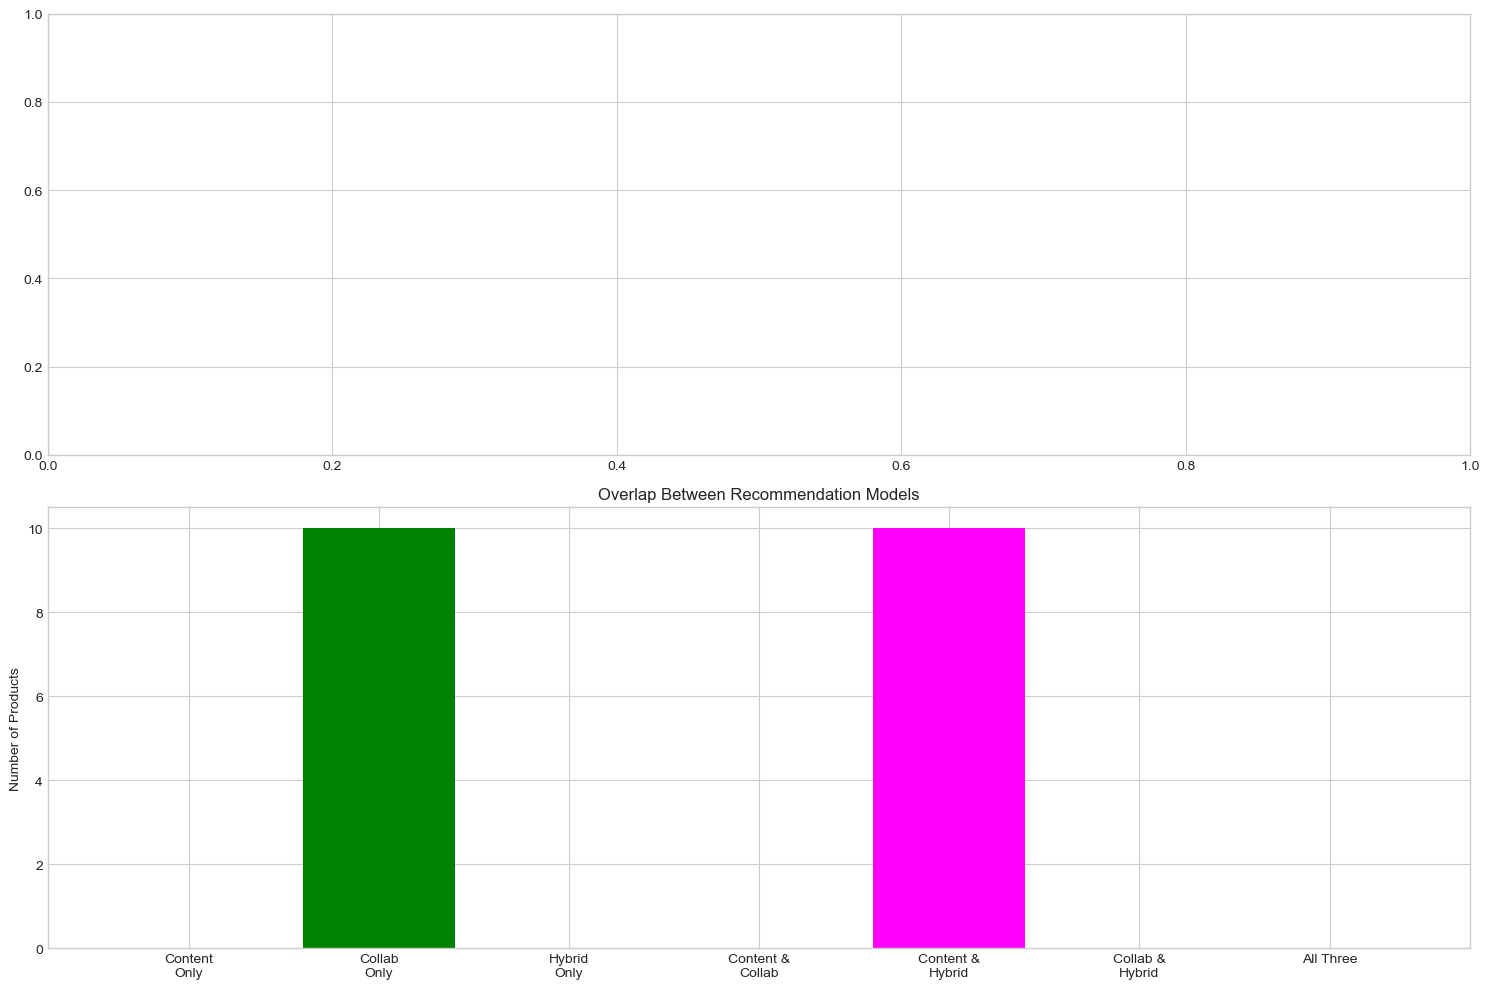


Top Hybrid Recommendations:
                                ProdID  \
4499  da71120cc99df38eac51754eb0d38e3b   
998   f59e5ed80215044470f24f4f313165f8   
4889  d5ec1093b8d8c52568a17c43e4d214e2   
1368  e912aafa92cecec513d9b30a46fd9cb6   
884   4e89a78cac193c5bb83f9ec63f464d66   
4783  98909f93546ac2e6551b3afa83b6be5c   
4182  f207b427c5826a0e7024bd0887df7bc8   
2749  3d5bcd3c567b21e3e5add12a99fb47a3   
4063  34c4e955817928aac365df7f4cf25db0   
4058  b483f12a6da228c6e420b567b45c5f6b   

                                                   Name  \
4499  Provon, GOJ538502, TFX Refill Moisturizer Foam...   
998   Gojo ADX-12 Clear & Mild Foam Hand Soap Refill...   
4889  Provon Soap Refill Bottle Clear and Mild, Foam...   
1368  Brighton Professional Professional ADX-12 Foam...   
884   Brighton Professional Professional ADX-12 Foam...   
4783  Gojo TFX Luxury Foam Hand Soap Refills, Fresh ...   
4182  Green Certified Foam Hand Cleaner, 2000ml Refi...   
2749  Foaming Handwash w/Moisturizer

In [77]:
# Get a random product ID to test with
random_product_id = df['ProdID'].sample(1).iloc[0]

# Generate hybrid recommendations
hybrid_recommendations = recommend_products_hybrid(
    user_id=None,  # Will use a random synthetic user
    product_id=random_product_id,
    product_df=df,
    n=10,
    n_users=100,
    content_weight=0.5,
    collab_weight=0.5,
    dynamic_weighting=True,  # Adjust weights based on user history
    evaluate=True,
    visualize=True
)

print("\nTop Hybrid Recommendations:")
print(hybrid_recommendations)